# Analisis Exploratorio del Dataset: Google Ads Analytics
**Objetivo:** Explorar el dataset de campanas publicitarias de Google Ads, limpiar los datos, realizar analisis exploratorio e ingenieria de caracteristicas para preparar el dataset para etapas de modelado posteriores.

**Diccionario de Variables Clave:**
* `Ad_ID`: Identificador unico de cada anuncio.
* `Ad_Date`: Fecha en que se publico el anuncio.
* `Campaign_Name`: Nombre de la campana publicitaria.
* `Device`: Dispositivo desde el que se visualizo el anuncio.
* `Location`: Ubicacion geografica del usuario.
* `Clicks`: Numero de clics recibidos por el anuncio.
* `Impressions`: Numero de veces que se mostro el anuncio.
* `Leads`: Numero de clientes potenciales generados.
* `Conversions`: Numero de conversiones completadas.
* `Conversion Rate`: Porcentaje de clics que resultaron en conversion.
* `Cost`: Costo de la campana publicitaria (en dolares).
* `Sale_Amount`: Monto total de ventas generadas (en dolares).
* `Is_Profitable`: Variable objetivo binaria (1 = rentable si Sale_Amount > Cost, 0 = no rentable).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuracion visual para que los graficos se vean profesionales
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Cargamos el dataset
df = pd.read_csv('../data/raw/GoogleAds_DataAnalytics_Sales_Uncleaned.csv')
print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (2600, 13)


,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword
0,A1000,DataAnalyticsCourse,104.0,4498.0,$231.88,14.0,7.0,0.058,$1892,2024-11-16,hyderabad,desktop,learn data analytics
1,A1001,DataAnalyticsCourse,173.0,5107.0,$216.84,10.0,8.0,0.046,$1679,20-11-2024,hyderabad,mobile,data analytics course
2,A1002,Data Anlytics Corse,90.0,4544.0,$203.66,26.0,9.0,NaN,$1624,2024/11/16,hyderabad,Desktop,data analitics online
3,A1003,Data Analytcis Course,142.0,3185.0,$237.66,17.0,6.0,NaN,$1225,2024-11-26,HYDERABAD,tablet,data anaytics training
4,A1004,Data Analytics Corse,156.0,3361.0,$195.9,30.0,8.0,NaN,$1091,2024-11-22,hyderabad,desktop,online data analytic


## 1. Inspeccion inicial y problemas de calidad
Revisamos tipos de datos, valores nulos y posibles inconsistencias en el dataset crudo.

In [2]:
# Revisamos tipos de datos y valores nulos por columna
print(df.dtypes)
print()
print('Nulos por columna:')
print(df.isnull().sum())

Ad_ID                  str
Campaign_Name          str
Clicks             float64
Impressions        float64
Cost                   str
Leads              float64
Conversions        float64
Conversion Rate    float64
Sale_Amount            str
Ad_Date                str
Location               str
Device                 str
Keyword                str
dtype: object

Nulos por columna:
Ad_ID                0
Campaign_Name        0
Clicks             112
Impressions         54
Cost                97
Leads               48
Conversions         74
Conversion Rate    626
Sale_Amount        139
Ad_Date              0
Location             0
Device               0
Keyword              0
dtype: int64


In [3]:
# Contamos las filas duplicadas exactas
print(f'Filas duplicadas: {df.duplicated().sum()}')
print(f'Ad_ID duplicados: {df["Ad_ID"].duplicated().sum()}')

Filas duplicadas: 0
Ad_ID duplicados: 0


In [4]:
# Estadisticas descriptivas de las columnas numericas originales
df.describe()

,Clicks,Impressions,Leads,Conversions,Conversion Rate
count,2488.000000,2546.000000,2552.000000,2526.000000,1974.000000
mean,138.956994,4523.280833,20.003918,6.519002,0.048979
std,34.619376,869.927913,6.032317,2.272573,0.019987
min,80.000000,3000.000000,10.000000,3.000000,0.015000
25%,110.000000,3764.000000,15.000000,5.000000,0.035000
50%,139.000000,4518.500000,20.000000,7.000000,0.046000
75%,169.000000,5279.500000,25.000000,9.000000,0.058000
max,199.000000,5999.000000,30.000000,10.000000,0.123000


## 2. Limpieza de Datos

In [5]:
# Eliminamos filas duplicadas
df = df.drop_duplicates()

# Normalizamos Device a minusculas para unificar variantes
df['Device'] = df['Device'].str.strip().str.lower()

# Corregimos errores ortograficos en Location
df['Location'] = df['Location'].str.strip().str.lower()
df['Location'] = df['Location'].replace({'hyderbad': 'hyderabad', 'hydrebad': 'hyderabad'})

# Corregimos errores ortograficos en Campaign_Name
df['Campaign_Name'] = df['Campaign_Name'].str.strip()
df['Campaign_Name'] = df['Campaign_Name'].replace({
    'Data Anlytics Corse': 'Data Analytics Course',
    'Data Analytcis Course': 'Data Analytics Course',
    'Data Analytics Corse': 'Data Analytics Course',
    'DataAnalyticsCourse': 'Data Analytics Course',
})

# Eliminamos el simbolo $ y convertimos Cost y Sale_Amount a float
df['Cost'] = pd.to_numeric(
    df['Cost'].astype(str).str.replace(r'[\$,]', '', regex=True).str.strip(),
    errors='coerce'
)
df['Sale_Amount'] = pd.to_numeric(
    df['Sale_Amount'].astype(str).str.replace(r'[\$,]', '', regex=True).str.strip(),
    errors='coerce'
)

# Parseamos Ad_Date con multiples formatos (ISO, DD-MM-YYYY, YYYY/MM/DD)
parsed = pd.to_datetime(df['Ad_Date'], format='mixed', dayfirst=False, errors='coerce')
mask_nat = parsed.isna()
parsed[mask_nat] = pd.to_datetime(df.loc[mask_nat, 'Ad_Date'], format='%d-%m-%Y', errors='coerce')
df['Ad_Date'] = parsed

# Eliminamos filas sin fecha (no imputables)
df = df.dropna(subset=['Ad_Date'])

# Imputamos columnas numericas con la mediana (robusta a outliers)
num_cols = ['Clicks', 'Impressions', 'Leads', 'Conversions', 'Cost', 'Sale_Amount']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Recalculamos Conversion Rate donde era nulo usando Conversions / Clicks
mask_cr = df['Conversion Rate'].isna()
df.loc[mask_cr, 'Conversion Rate'] = (
    df.loc[mask_cr, 'Conversions'] / df.loc[mask_cr, 'Clicks']
)
df['Conversion Rate'] = df['Conversion Rate'].fillna(df['Conversion Rate'].median())

# Aplicamos Winsorizacion IQR para tratar outliers sin eliminar filas
outlier_cols = ['Clicks', 'Impressions', 'Cost', 'Sale_Amount', 'Leads', 'Conversions']
for col in outlier_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df[col] = df[col].clip(lower=lo, upper=hi)

print(f'Shape final del dataset limpio: {df.shape}')
print('Nulos restantes:')
print(df.isnull().sum())

Shape final del dataset limpio: (2600, 13)
Nulos restantes:
Ad_ID              0
Campaign_Name      0
Clicks             0
Impressions        0
Cost               0
Leads              0
Conversions        0
Conversion Rate    0
Sale_Amount        0
Ad_Date            0
Location           0
Device             0
Keyword            0
dtype: int64


## 3. EDA

In [6]:
# Estadisticas descriptivas tras la limpieza
df.describe()

,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date
count,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600.000000,2600
mean,138.958846,4523.181538,215.108508,20.003846,6.532692,0.049510,1498.987692,2024-10-30 10:22:31.384615
min,80.000000,3000.000000,180.010000,10.000000,3.000000,0.015000,1000.000000,2024-01-11 00:00:00
25%,111.000000,3778.000000,198.385000,15.000000,5.000000,0.035000,1262.000000,2024-11-07 18:00:00
50%,139.000000,4518.500000,215.570000,20.000000,7.000000,0.047000,1505.000000,2024-11-16 00:00:00
75%,167.000000,5268.250000,232.297500,25.000000,8.000000,0.059000,1728.000000,2024-11-23 00:00:00
max,199.000000,5999.000000,249.890000,30.000000,10.000000,0.123000,2000.000000,2024-12-11 00:00:00
std,33.865228,860.843403,19.907580,5.976353,2.241415,0.020353,279.327209,NaN


Generando distribuciones numericas...


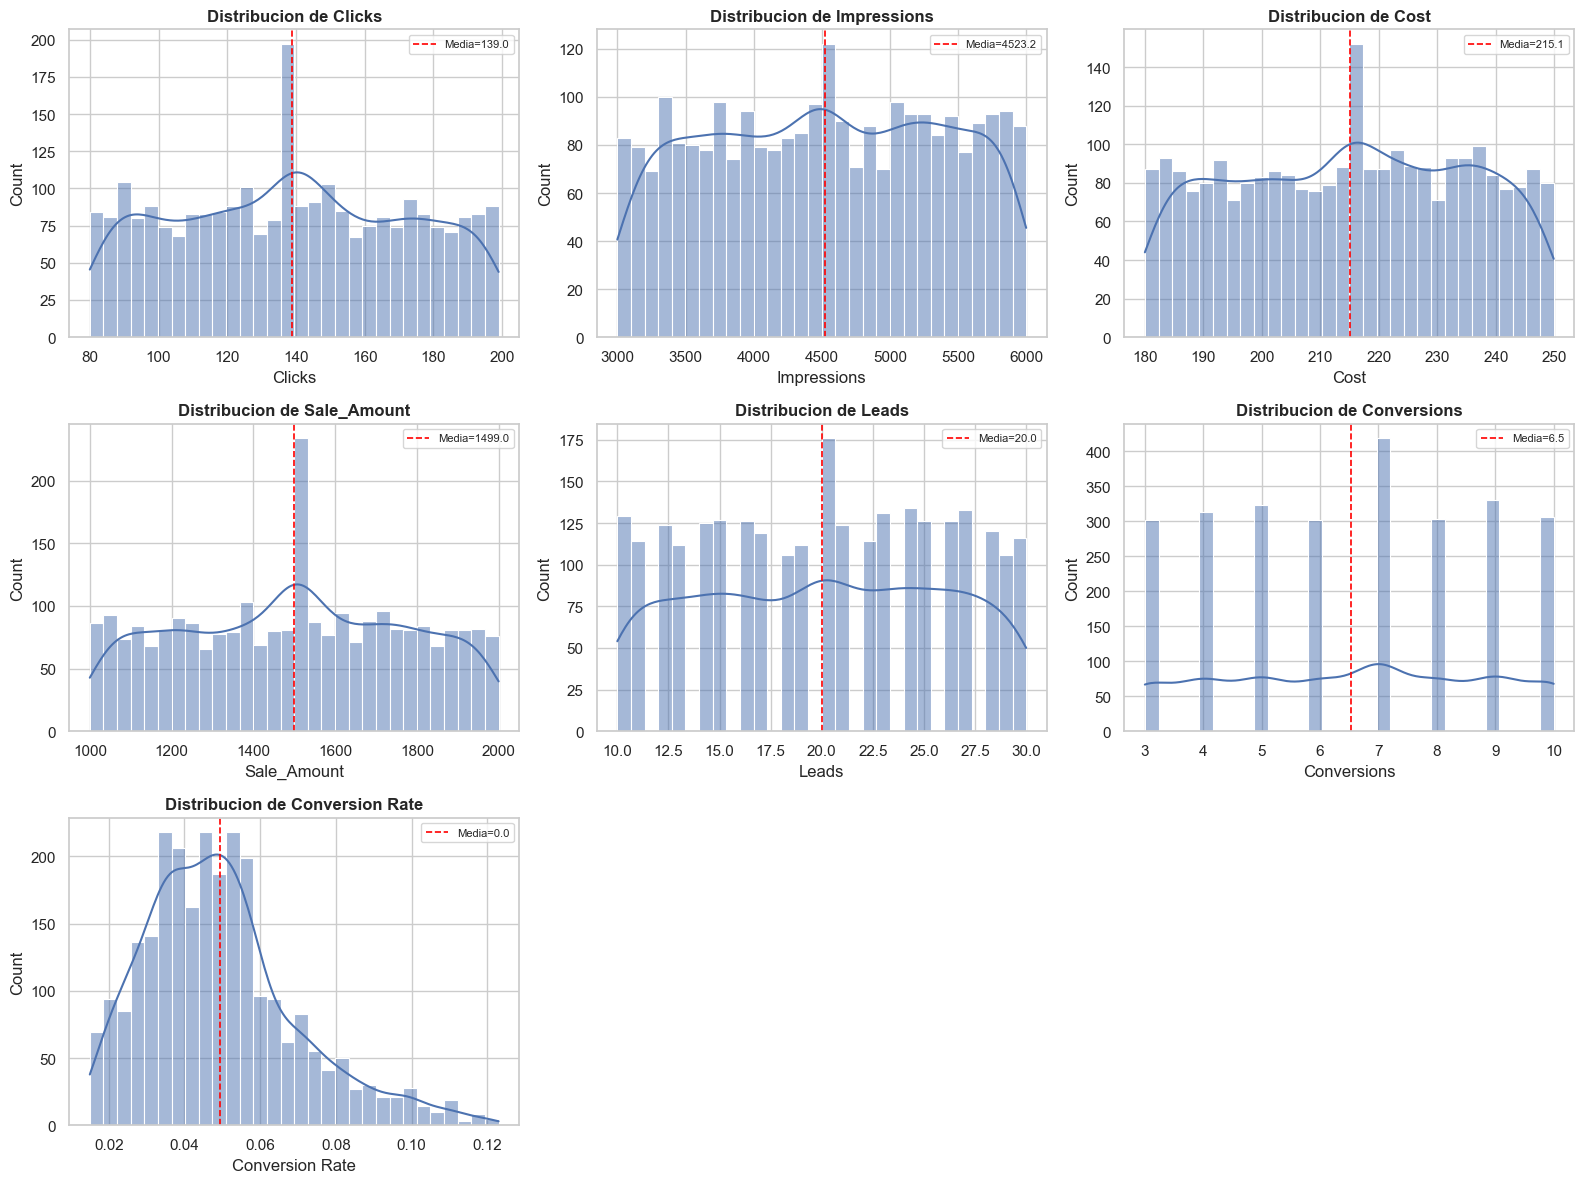

In [7]:
print('Generando distribuciones numericas...')
num_feats = ['Clicks', 'Impressions', 'Cost', 'Sale_Amount', 'Leads', 'Conversions', 'Conversion Rate']

# Graficamos la distribucion de cada variable numerica
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(num_feats):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribucion de {col}', fontweight='bold')
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.2,
                    label=f'Media={df[col].mean():.1f}')
    axes[i].legend(fontsize=8)
for j in range(len(num_feats), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/dist_numericas.png', bbox_inches='tight', dpi=150)
plt.show()

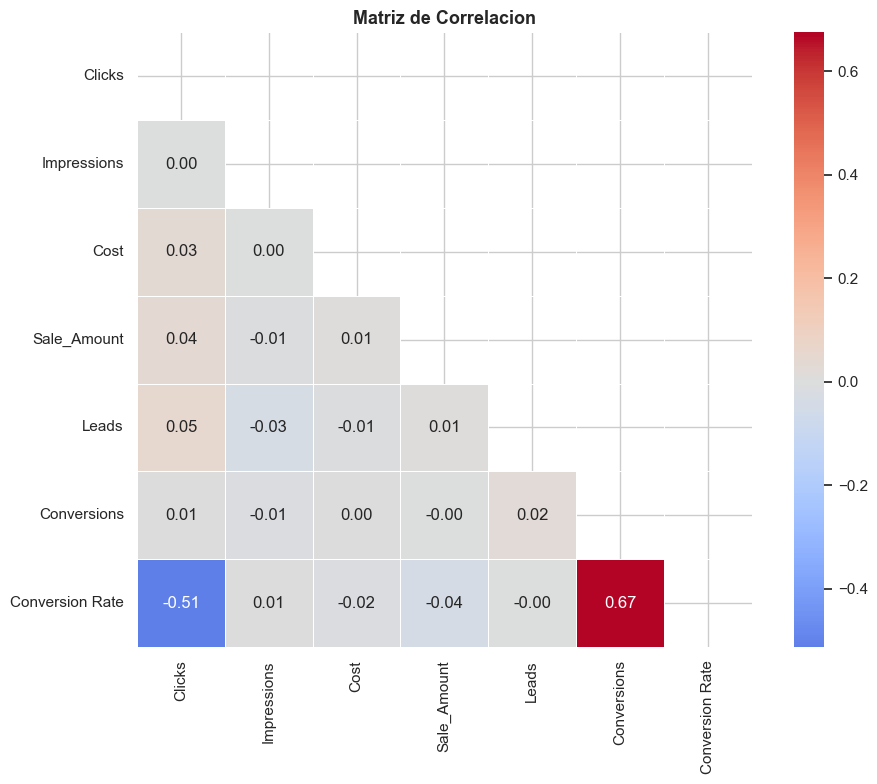

Correlacion con Sale_Amount:
Sale_Amount        1.000000
Clicks             0.035281
Leads              0.011585
Cost               0.010426
Conversions       -0.002676
Impressions       -0.008152
Conversion Rate   -0.037867


In [8]:
# Calculamos y graficamos la matriz de correlacion entre variables numericas
corr = df[num_feats].corr()
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, ax=ax, square=True)
ax.set_title('Matriz de Correlacion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlacion.png', bbox_inches='tight', dpi=150)
plt.show()

# Mostramos las correlaciones mas fuertes con Sale_Amount
print('Correlacion con Sale_Amount:')
print(corr['Sale_Amount'].sort_values(ascending=False).to_string())

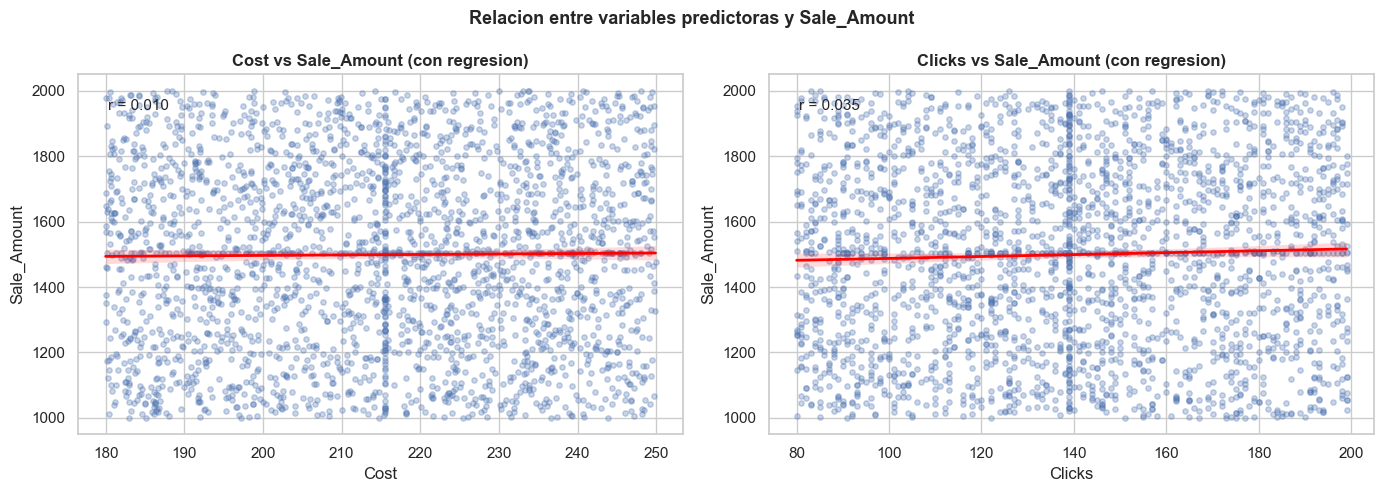

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Cost vs Sale_Amount con linea de regresion
sns.regplot(data=df, x='Cost', y='Sale_Amount', ax=axes[0],
            scatter_kws={'alpha': 0.3, 's': 15},
            line_kws={'color': 'red', 'linewidth': 2})
axes[0].set_title('Cost vs Sale_Amount (con regresion)', fontweight='bold')
r_cost = df['Cost'].corr(df['Sale_Amount'])
axes[0].text(0.05, 0.9, f'r = {r_cost:.3f}', transform=axes[0].transAxes, fontsize=11)

# Scatter Clicks vs Sale_Amount con linea de regresion
sns.regplot(data=df, x='Clicks', y='Sale_Amount', ax=axes[1],
            scatter_kws={'alpha': 0.3, 's': 15},
            line_kws={'color': 'red', 'linewidth': 2})
axes[1].set_title('Clicks vs Sale_Amount (con regresion)', fontweight='bold')
r_clicks = df['Clicks'].corr(df['Sale_Amount'])
axes[1].text(0.05, 0.9, f'r = {r_clicks:.3f}', transform=axes[1].transAxes, fontsize=11)

plt.suptitle('Relacion entre variables predictoras y Sale_Amount', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/scatter_regresion.png', bbox_inches='tight', dpi=150)
plt.show()

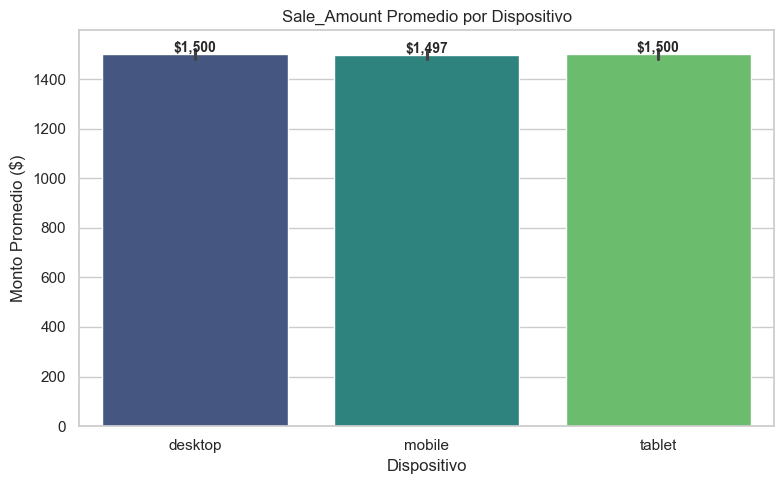

In [10]:
# Comparamos el Sale_Amount promedio por tipo de dispositivo
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=df, x='Device', y='Sale_Amount',
                 estimator='mean', palette='viridis',
                 order=sorted(df['Device'].unique()))
plt.title('Sale_Amount Promedio por Dispositivo')
plt.ylabel('Monto Promedio ($)')
plt.xlabel('Dispositivo')
total = df.groupby('Device')['Sale_Amount'].mean()
for p in ax.patches:
    ax.annotate(f'\${p.get_height():,.0f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/rendimiento_dispositivo.png', bbox_inches='tight', dpi=150)
plt.show()

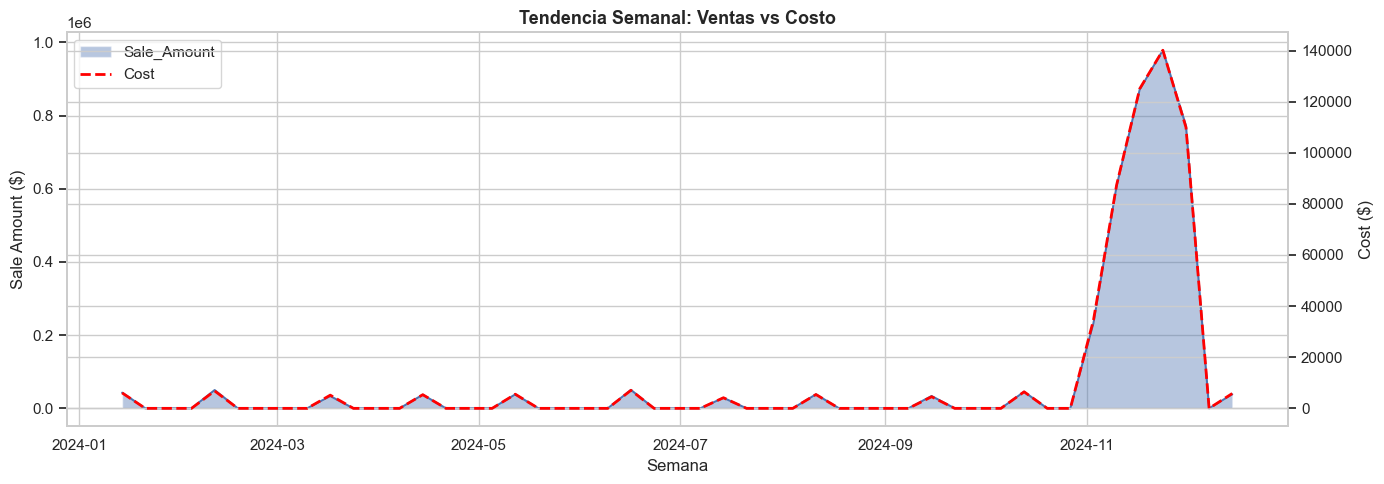

In [11]:
# Agrupamos ventas y costo por semana para ver la tendencia temporal
df_time = (
    df.set_index('Ad_Date')
      .resample('W')[['Sale_Amount', 'Cost']]
      .sum()
      .reset_index()
)
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.fill_between(df_time['Ad_Date'], df_time['Sale_Amount'], alpha=0.4, label='Sale_Amount')
ax1.plot(df_time['Ad_Date'], df_time['Sale_Amount'], linewidth=1.5)
ax2.plot(df_time['Ad_Date'], df_time['Cost'], color='red', linewidth=2,
         linestyle='--', label='Cost')
ax1.set_ylabel('Sale Amount ($)')
ax2.set_ylabel('Cost ($)')
ax1.set_xlabel('Semana')
ax1.set_title('Tendencia Semanal: Ventas vs Costo', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('../outputs/tendencia_temporal.png', bbox_inches='tight', dpi=150)
plt.show()

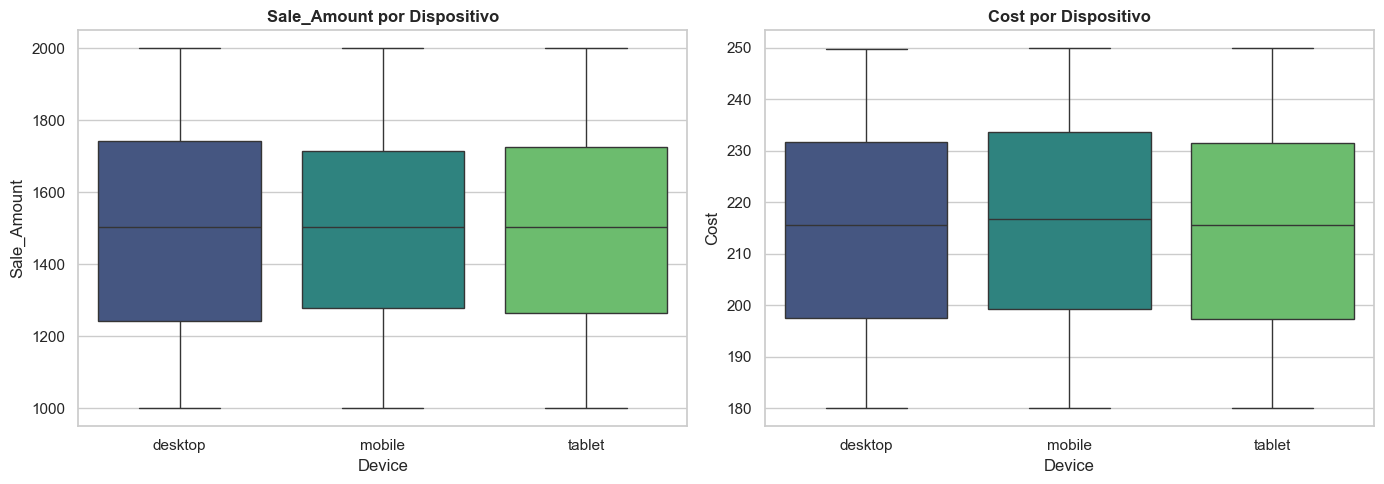

In [12]:
# Boxplots de Sale_Amount y Cost por dispositivo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Device', y='Sale_Amount', ax=axes[0], palette='viridis',
            order=sorted(df['Device'].unique()))
axes[0].set_title('Sale_Amount por Dispositivo', fontweight='bold')
sns.boxplot(data=df, x='Device', y='Cost', ax=axes[1], palette='viridis',
            order=sorted(df['Device'].unique()))
axes[1].set_title('Cost por Dispositivo', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/boxplot_dispositivo.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Ingenieria de Caracteristicas

In [13]:
# Extraemos el dia de la semana a partir de la fecha
day_map = {0:'Lunes', 1:'Martes', 2:'Miercoles', 3:'Jueves',
           4:'Viernes', 5:'Sabado', 6:'Domingo'}
df['Day_of_Week'] = df['Ad_Date'].dt.dayofweek.map(day_map)
df['Month'] = df['Ad_Date'].dt.month

# Calculamos el ROAS (Return on Ad Spend): dinero generado por cada dolar invertido
df['ROAS'] = df['Sale_Amount'] / df['Cost'].replace(0, np.nan)

# Calculamos el CTR (Click-Through Rate): clics sobre impresiones
df['CTR'] = df['Clicks'] / df['Impressions'].replace(0, np.nan)

# Calculamos el CPC (Costo por Clic)
df['CPC'] = df['Cost'] / df['Clicks'].replace(0, np.nan)

# Creamos la variable objetivo Is_Profitable: 1 si Sale_Amount > Cost, 0 en caso contrario
# Se genera mediante la comparacion entre Sale_Amount y Cost, permitiendo evaluar
# el exito financiero de cada anuncio de forma binaria para etapas posteriores de clasificacion.
df['Is_Profitable'] = (df['Sale_Amount'] > df['Cost']).astype(int)

print(f'Campanas rentables (Sale_Amount > Cost): '
      f'{df["Is_Profitable"].sum():,} de {len(df):,} ({df["Is_Profitable"].mean()*100:.1f}%)')
df[['Day_of_Week', 'ROAS', 'CTR', 'CPC', 'Is_Profitable']].describe()

Campanas rentables (Sale_Amount > Cost): 2,600 de 2,600 (100.0%)


,ROAS,CTR,CPC,Is_Profitable
count,2600.000000,2600.000000,2600.000000,2600.0
mean,7.028136,0.031927,1.650389,1.0
std,1.468858,0.010277,0.462157,0.0
min,4.065534,0.013632,0.909394,1.0
25%,5.888577,0.024255,1.286494,1.0
50%,6.939455,0.030384,1.546189,1.0
75%,8.105256,0.038155,1.933303,1.0
max,11.052632,0.065470,3.089500,1.0


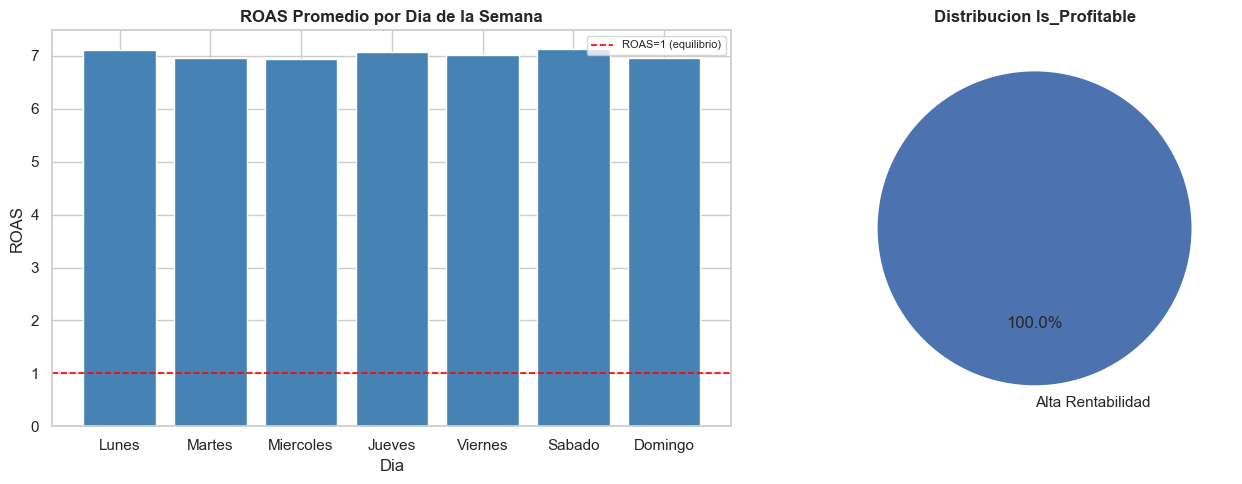

In [14]:
dias_orden = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']

# ROAS promedio por dia de la semana
roas_dia = (
    df.groupby('Day_of_Week')['ROAS']
      .mean()
      .reindex([d for d in dias_orden if d in df['Day_of_Week'].unique()])
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras del ROAS promedio con linea de equilibrio ROAS=1
axes[0].bar(roas_dia['Day_of_Week'], roas_dia['ROAS'], color='steelblue', edgecolor='white')
axes[0].axhline(y=1, color='red', linewidth=1.2, linestyle='--', label='ROAS=1 (equilibrio)')
axes[0].set_title('ROAS Promedio por Dia de la Semana', fontweight='bold')
axes[0].set_xlabel('Dia')
axes[0].set_ylabel('ROAS')
axes[0].legend(fontsize=8)

# Distribucion de campanas rentables vs no rentables
profit_counts = df['Is_Profitable'].value_counts().sort_index()
label_map = {0: 'Baja Rentabilidad', 1: 'Alta Rentabilidad'}
pie_labels = [label_map.get(k, str(k)) for k in profit_counts.index]
axes[1].pie(profit_counts.values, labels=pie_labels,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Distribucion Is_Profitable', fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/roas_y_rentabilidad.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Exportacion del Dataset Procesado
Guardamos el dataset limpio y enriquecido listo para etapas de modelado posteriores.

In [15]:
# Exportamos el dataset limpio con las nuevas features
out_path = '../outputs/GoogleAds_Processed.csv'
df.to_csv(out_path, index=False)

# Verificamos que el archivo tiene el mismo numero de filas
df_check = pd.read_csv(out_path)
assert len(df_check) == len(df), 'Error: numero de filas diferente'
print(f'Dataset exportado: {out_path}')
print(f'Filas: {len(df_check):,}  |  Columnas: {df_check.shape[1]}')
df_check.head()

Dataset exportado: ../data/processed/GoogleAds_Processed.csv
Filas: 2,600  |  Columnas: 19


,Ad_ID,Campaign_Name,Clicks,Impressions,Cost,Leads,Conversions,Conversion Rate,Sale_Amount,Ad_Date,Location,Device,Keyword,Day_of_Week,Month,ROAS,CTR,CPC,Is_Profitable
0,A1000,Data Analytics Course,104.0,4498.0,231.88,14.0,7.0,0.058000,1892.0,2024-11-16,hyderabad,desktop,learn data analytics,Sabado,11,8.159393,0.023121,2.229615,1
1,A1001,Data Analytics Course,173.0,5107.0,216.84,10.0,8.0,0.046000,1679.0,2024-11-20,hyderabad,mobile,data analytics course,Miercoles,11,7.743036,0.033875,1.253410,1
2,A1002,Data Analytics Course,90.0,4544.0,203.66,26.0,9.0,0.100000,1624.0,2024-11-16,hyderabad,desktop,data analitics online,Sabado,11,7.974074,0.019806,2.262889,1
3,A1003,Data Analytics Course,142.0,3185.0,237.66,17.0,6.0,0.042254,1225.0,2024-11-26,hyderabad,tablet,data anaytics training,Martes,11,5.154422,0.044584,1.673662,1
4,A1004,Data Analytics Course,156.0,3361.0,195.90,30.0,8.0,0.051282,1091.0,2024-11-22,hyderabad,desktop,online data analytic,Viernes,11,5.569168,0.046415,1.255769,1


## 6. Conclusiones

### Limpieza de Datos
- Se normalizaron `Device`, `Location` y `Campaign_Name` eliminando inconsistencias.
- `Cost` y `Sale_Amount` se convirtieron de string con `$` a `float64`.
- Las fechas con multiples formatos se unificaron correctamente.
- Los valores nulos se imputaron con la **mediana**.
- Los outliers se trataron con **Winsorizacion IQR** para conservar todos los registros.

### Ingenieria de Caracteristicas

| Feature | Formula | Descripcion |
|---|---|---|
| `ROAS` | Sale_Amount / Cost | Retorno por dolar invertido en publicidad |
| `CTR` | Clicks / Impressions | Relevancia del anuncio |
| `CPC` | Cost / Clicks | Costo por clic |
| `Day_of_Week` | dt.dayofweek | Dia de la semana del anuncio |
| `Is_Profitable` | Sale_Amount > Cost | Variable objetivo binaria para clasificacion posterior |

El dataset procesado queda guardado en `data/processed/GoogleAds_Processed.csv`.
